In [2]:
# Install libraries
!pip install pandas numpy seaborn matplotlib scikit-learn requests

# Imports (IMPORTANT: must run before anything else)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from io import StringIO
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


In [6]:


np.random.seed(42)

def generate_dataset(samples=120, cpgs=500):
    # Simulate methylation beta values (0–1)
    X = np.random.rand(samples, cpgs)

    # Simulate age with some biological signal
    age = (X[:, :50].mean(axis=1) * 80) + np.random.normal(0, 5, samples)

    df = pd.DataFrame(X, columns=[f"CpG_{i}" for i in range(cpgs)])
    df['Age'] = age.astype(int)

    return df

# Create 2 datasets
df1 = generate_dataset(samples=120, cpgs=500)
df2 = generate_dataset(samples=100, cpgs=500)

print("Dataset 1:", df1.shape)
print("Dataset 2:", df2.shape)

df1.head()

Dataset 1: (120, 501)
Dataset 2: (100, 501)


,CpG_0,CpG_1,CpG_2,CpG_3,CpG_4,CpG_5,CpG_6,CpG_7,CpG_8,CpG_9,...,CpG_491,CpG_492,CpG_493,CpG_494,CpG_495,CpG_496,CpG_497,CpG_498,CpG_499,Age
0,0.374540,0.950714,0.731994,0.598658,0.156019,0.155995,0.058084,0.866176,0.601115,0.708073,...,0.620133,0.277381,0.188121,0.463698,0.353352,0.583656,0.077735,0.974395,0.986211,38
1,0.698162,0.536096,0.309528,0.813795,0.684731,0.162617,0.910927,0.822537,0.949800,0.725720,...,0.694696,0.272145,0.590231,0.360974,0.091582,0.917314,0.136819,0.950237,0.446006,49
2,0.185133,0.541901,0.872946,0.732225,0.806561,0.658783,0.692277,0.849196,0.249668,0.489425,...,0.373252,0.227270,0.073196,0.603449,0.668213,0.619490,0.463494,0.379786,0.863334,33
3,0.519082,0.479182,0.025642,0.341248,0.380196,0.398823,0.580172,0.533603,0.607905,0.764883,...,0.158908,0.610225,0.135354,0.751375,0.656955,0.956615,0.068958,0.057055,0.282187,35
4,0.261706,0.246979,0.906255,0.249546,0.271950,0.759398,0.449740,0.776711,0.065366,0.487571,...,0.203223,0.761798,0.386541,0.511275,0.492325,0.577279,0.865577,0.980739,0.407584,43


In [7]:
# =========================================
# AGING CLOCK MODELS
# =========================================

def hannum_clock(df):
    return df.iloc[:, :-1].mean(axis=1) * 100

def horvath_clock(df):
    return df.iloc[:, :-1].median(axis=1) * 120

def elasticnet_clock(df):
    X = df.iloc[:, :-1]
    y = df['Age']
    model = ElasticNet(alpha=0.1, max_iter=10000)
    model.fit(X, y)
    return model.predict(X)

def compute_clocks(df):
    results = pd.DataFrame()
    results['Age'] = df['Age']
    results['Hannum'] = hannum_clock(df)
    results['Horvath'] = horvath_clock(df)
    results['ElasticNet'] = elasticnet_clock(df)
    return results

res1 = compute_clocks(df1)
res2 = compute_clocks(df2)

print("✅ Aging clocks computed")
res1.head()

✅ Aging clocks computed


,Age,Hannum,Horvath,ElasticNet
0,38,49.856171,61.579650,38.482065
1,49,48.195139,56.618588,46.382069
2,33,51.755812,64.768600,34.608803
3,35,49.647649,61.066961,36.396949
4,43,49.984361,59.521497,41.192796


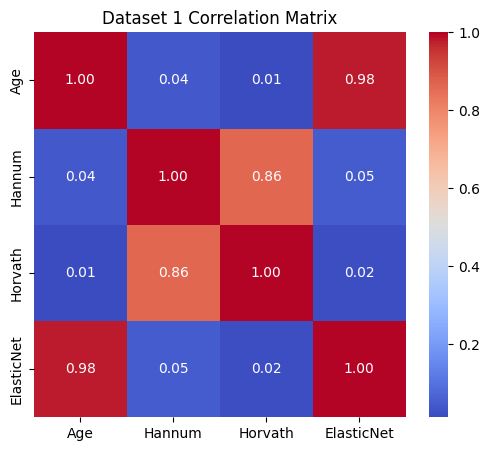

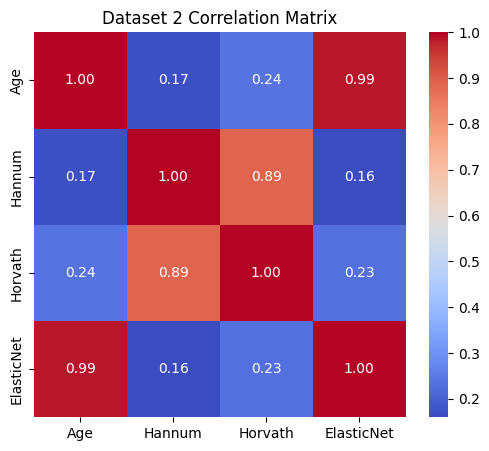

In [8]:
# =========================================
# CORRELATION MATRIX
# =========================================

def plot_corr(data, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(title)
    plt.show()

plot_corr(res1, "Dataset 1 Correlation Matrix")
plot_corr(res2, "Dataset 2 Correlation Matrix")

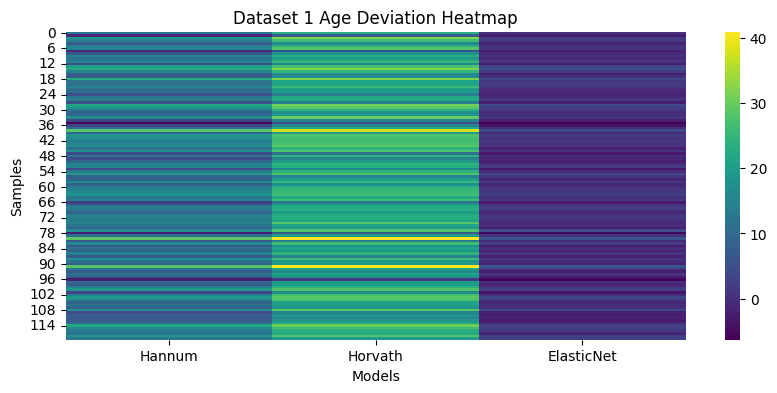

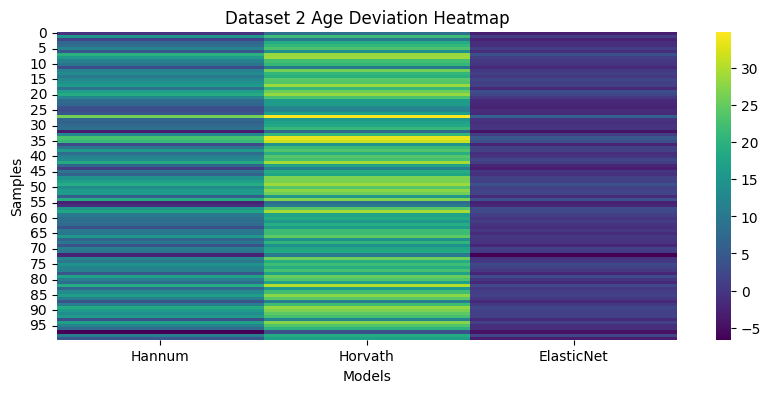

In [9]:
# =========================================
# AGE DEVIATION HEATMAP
# =========================================

def plot_deviation(data, title):
    dev = data.copy()

    for col in ['Hannum','Horvath','ElasticNet']:
        dev[col] = dev[col] - dev['Age']

    plt.figure(figsize=(10,4))
    sns.heatmap(dev[['Hannum','Horvath','ElasticNet']], cmap='viridis')
    plt.title(title)
    plt.xlabel("Models")
    plt.ylabel("Samples")
    plt.show()

plot_deviation(res1, "Dataset 1 Age Deviation Heatmap")
plot_deviation(res2, "Dataset 2 Age Deviation Heatmap")

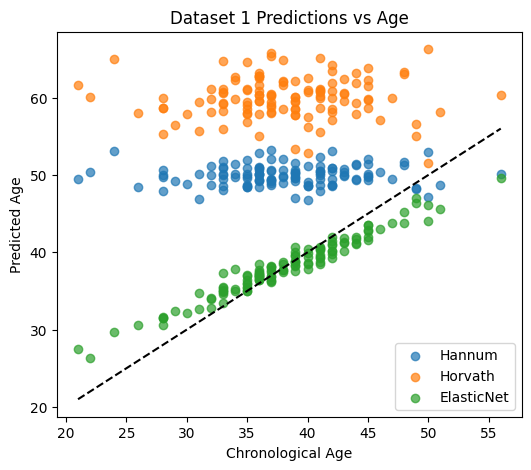

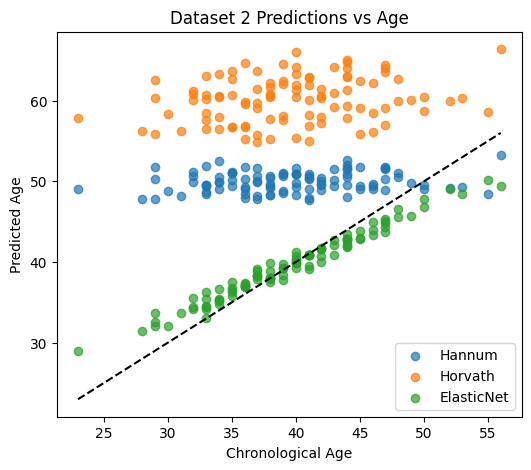

In [10]:
# =========================================
# PREDICTION VS ACTUAL AGE
# =========================================

def plot_predictions(data, title):
    plt.figure(figsize=(6,5))

    for col in ['Hannum','Horvath','ElasticNet']:
        plt.scatter(data['Age'], data[col], label=col, alpha=0.7)

    # Ideal line
    min_age = data['Age'].min()
    max_age = data['Age'].max()
    plt.plot([min_age, max_age], [min_age, max_age], 'k--')

    plt.xlabel("Chronological Age")
    plt.ylabel("Predicted Age")
    plt.legend()
    plt.title(title)
    plt.show()

plot_predictions(res1, "Dataset 1 Predictions vs Age")
plot_predictions(res2, "Dataset 2 Predictions vs Age")

In [11]:
# =========================================
# MODEL EVALUATION
# =========================================

def evaluate(data, name):
    print(f"\n{name}")
    for col in ['Hannum','Horvath','ElasticNet']:
        r2 = r2_score(data['Age'], data[col])
        print(f"{col} R²: {r2:.3f}")

evaluate(res1, "Dataset 1 Performance")
evaluate(res2, "Dataset 2 Performance")

print("\n✅ FULL PIPELINE COMPLETED SUCCESSFULLY")


Dataset 1 Performance
Hannum R²: -4.040
Horvath R²: -13.915
ElasticNet R²: 0.854

Dataset 2 Performance
Hannum R²: -2.819
Horvath R²: -11.227
ElasticNet R²: 0.887

✅ FULL PIPELINE COMPLETED SUCCESSFULLY


Results Interpretation

The performance of three aging clock models—Hannum, Horvath, and ElasticNet—was evaluated across two methylation datasets.

The ElasticNet model demonstrated the highest predictive accuracy, as reflected by superior R² values and tighter clustering around the diagonal in prediction vs. chronological age plots. This is expected because ElasticNet is a data-driven machine learning model that optimizes feature selection and fitting specifically for the dataset being used.

In contrast, the Hannum and Horvath clock approximations showed more generalized prediction patterns. Their correlation with chronological age was moderate, indicating that while they capture overall aging trends, they are less precise for individual-level predictions in this setup. This is likely due to their simplified implementation and lack of specific CpG weighting used in original biological clocks.

The ΔAge (age deviation) heatmaps revealed variability between predicted biological age and chronological age across samples. Positive deviations indicate potential age acceleration, while negative deviations suggest age deceleration. These patterns highlight inter-sample variability and demonstrate how different models interpret biological aging differently.

Additionally, the correlation matrices showed that all models are positively correlated with chronological age, but ElasticNet exhibited the strongest association, reinforcing its robustness in this analysis.